In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
df = pd.read_csv("../data/processed/olist_orders_abt.csv")

df.head()

,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_year,order_month,order_day,order_day_of_week,...,total_payment_value,max_payment_installments,payment_types_count,dominant_payment_type,total_items,total_price,total_freight,unique_products,unique_sellers,main_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017,10,2,0,...,38.71,1.0,2.0,voucher,1.0,29.99,8.72,1.0,1.0,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018,7,24,1,...,141.46,1.0,1.0,boleto,1.0,118.70,22.76,1.0,1.0,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018,8,8,2,...,179.12,3.0,1.0,credit_card,1.0,159.90,19.22,1.0,1.0,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,delivered,2017,11,18,5,...,72.20,1.0,1.0,credit_card,1.0,45.00,27.20,1.0,1.0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,delivered,2018,2,13,1,...,28.62,1.0,1.0,credit_card,1.0,19.90,8.72,1.0,1.0,stationery


In [3]:
df.shape

(99441, 29)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  99441 non-null  str    
 1   customer_id               99441 non-null  str    
 2   customer_unique_id        99441 non-null  str    
 3   customer_city             99441 non-null  str    
 4   customer_state            99441 non-null  str    
 5   order_status              99441 non-null  str    
 6   order_year                99441 non-null  int64  
 7   order_month               99441 non-null  int64  
 8   order_day                 99441 non-null  int64  
 9   order_day_of_week         99441 non-null  int64  
 10  order_hour                99441 non-null  int64  
 11  delivery_days             96476 non-null  float64
 12  estimated_delivery_days   99441 non-null  int64  
 13  delivery_delay_days       96476 non-null  float64
 14  is_late_delivery 

In [5]:
df.describe()

,order_year,order_month,order_day,order_day_of_week,order_hour,delivery_days,estimated_delivery_days,delivery_delay_days,is_late_delivery,review_score,...,review_comment_count,has_review_comment,total_payment_value,max_payment_installments,payment_types_count,total_items,total_price,total_freight,unique_products,unique_sellers
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,96476.000000,99441.000000,96476.000000,99441.000000,98673.000000,...,98673.000000,98673.000000,99440.000000,99440.000000,99440.000000,98666.000000,98666.000000,98666.000000,98666.000000,98666.000000
mean,2017.539838,6.032220,15.505948,2.755735,14.770829,12.094086,23.403958,-11.876881,0.065717,4.086793,...,0.415281,0.413852,160.990267,2.930521,1.022586,1.141731,137.754076,22.823562,1.038098,1.013622
std,0.505007,3.232999,8.667298,1.966495,5.326800,9.551746,8.829562,10.183854,0.247789,1.346274,...,0.495685,0.492525,221.951257,2.715685,0.148582,0.538452,210.645145,21.650909,0.226456,0.122297
min,2016.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,-147.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.850000,0.000000,1.000000,1.000000
25%,2017.000000,3.000000,8.000000,1.000000,11.000000,6.000000,18.000000,-17.000000,0.000000,4.000000,...,0.000000,0.000000,62.010000,1.000000,1.000000,1.000000,45.900000,13.850000,1.000000,1.000000
50%,2018.000000,6.000000,15.000000,3.000000,15.000000,10.000000,23.000000,-12.000000,0.000000,5.000000,...,0.000000,0.000000,105.290000,2.000000,1.000000,1.000000,86.900000,17.170000,1.000000,1.000000
75%,2018.000000,8.000000,23.000000,4.000000,19.000000,15.000000,28.000000,-7.000000,0.000000,5.000000,...,1.000000,1.000000,176.970000,4.000000,1.000000,1.000000,149.900000,24.040000,1.000000,1.000000
max,2018.000000,12.000000,31.000000,6.000000,23.000000,209.000000,155.000000,188.000000,1.000000,5.000000,...,3.000000,1.000000,13664.080000,24.000000,2.000000,21.000000,13440.000000,1794.960000,8.000000,5.000000


Columns with very large maximum values compared to their median: total_price, total_payment_value, total_freight, total_items, estimated_delivery_days,delivery_delay_days and max_payment_installments. 

In [6]:
nominal_columns = [
    "customer_state",
    "customer_city",
    "main_product_category", 
    "dominant_payment_type", 
    "order_status"
]

ordinal_columns = ["review_score"]

interval_columns = [
    "order_hour", 
    "order_month", 
    "order_day_of_week"
]

ratio_columns = [
    "total_payment_value", 
    "total_price", 
    "total_freight", 
    "delivery_days", 
    "estimated_delivery_days", 
    "delivery_delay_days", 
    "total_items", 
    "unique_products", 
    "unique_sellers"
]

In [7]:
df.columns

Index(['order_id', 'customer_id', 'customer_unique_id', 'customer_city',
       'customer_state', 'order_status', 'order_year', 'order_month',
       'order_day', 'order_day_of_week', 'order_hour', 'delivery_days',
       'estimated_delivery_days', 'delivery_delay_days', 'is_late_delivery',
       'review_score', 'is_low_review', 'review_comment_count',
       'has_review_comment', 'total_payment_value', 'max_payment_installments',
       'payment_types_count', 'dominant_payment_type', 'total_items',
       'total_price', 'total_freight', 'unique_products', 'unique_sellers',
       'main_product_category'],
      dtype='str')

In [8]:
def keep_existing_columns(dataframe, columns):
    return [col for col in columns if col in dataframe.columns]

nominal_columns = keep_existing_columns(df, nominal_columns)
ordinal_columns = keep_existing_columns(df, ordinal_columns)
interval_columns = keep_existing_columns(df, interval_columns)
ratio_columns = keep_existing_columns(df, ratio_columns)

In [9]:
if "delivery_days" in df.columns:
    df["delivery_speed_category"] = pd.cut(
        df["delivery_days"],
        bins=[-1, 7, 15, 30, np.inf],
        labels=["Fast", "Normal", "Slow", "Very Delayed"]
    )



In [10]:
if "total_payment_value" in df.columns:
    df["payment_value_band"] = pd.qcut(
        df["total_payment_value"],
        q=4,
        labels=["Low", "Medium", "High", "Premium"],
        duplicates="drop"
    )

In [11]:
df.isnull().sum()

order_id                       0
customer_id                    0
customer_unique_id             0
customer_city                  0
customer_state                 0
order_status                   0
order_year                     0
order_month                    0
order_day                      0
order_day_of_week              0
order_hour                     0
delivery_days               2965
estimated_delivery_days        0
delivery_delay_days         2965
is_late_delivery               0
review_score                 768
is_low_review                  0
review_comment_count         768
has_review_comment           768
total_payment_value            1
max_payment_installments       1
payment_types_count            1
dominant_payment_type          1
total_items                  775
total_price                  775
total_freight                775
unique_products              775
unique_sellers               775
main_product_category       2185
delivery_speed_category     2965
payment_va

In [12]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().sum() / len(df)) * 100
}).sort_values(by="missing_percent", ascending=False)

missing_summary.head(20)

,missing_count,missing_percent
delivery_delay_days,2965,2.981668
delivery_days,2965,2.981668
delivery_speed_category,2965,2.981668
main_product_category,2185,2.197283
total_price,775,0.779357
unique_sellers,775,0.779357
total_freight,775,0.779357
total_items,775,0.779357
unique_products,775,0.779357
review_score,768,0.772317


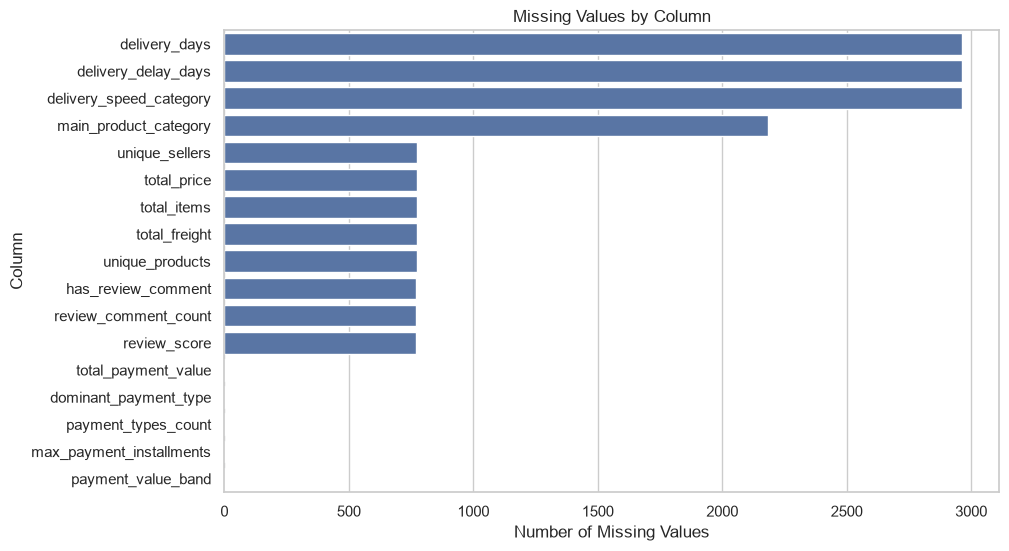

In [13]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

sns.barplot(
    x=missing_values.values,
    y=missing_values.index
)

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Column")
plt.show()

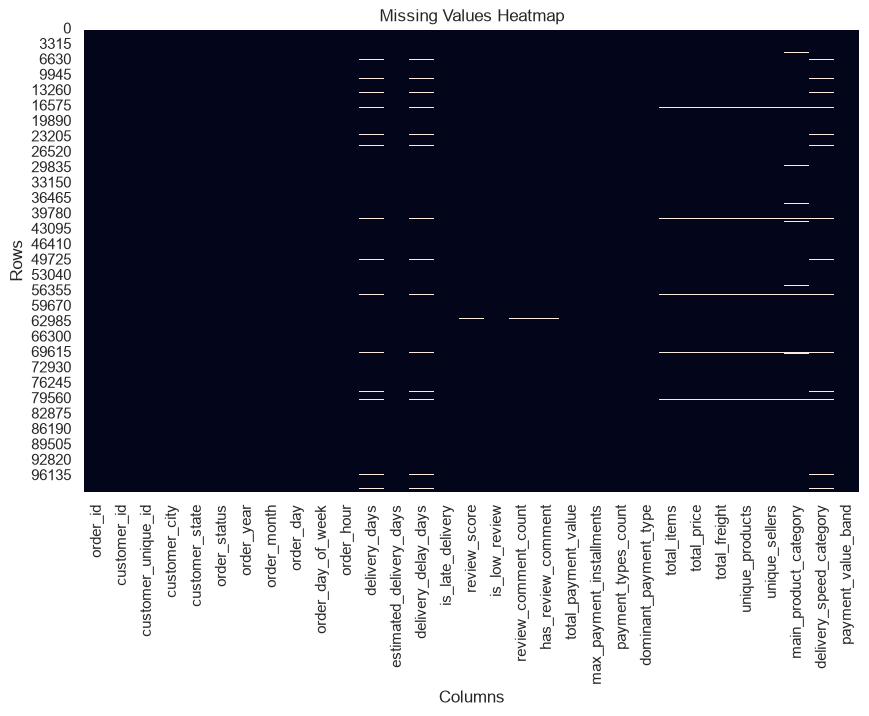

In [14]:
sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()


### 1. Which columns have missing values?

'delivery_days', 'delivery_delay_days','delivery_speed_category','main_product_category','total_price', 'total_items', 'total_freight','unique_sellers', 'unique_products', 'review_score','review_comment_count', 'has_review_comment', 'payment_types_count','max_payment_installments','total_payment_value','dominant_payment_type'

### 2. Which feature has the highest missing percentage?

`delivery_days`, `delivery_delay_days` and `delivery_speed_category` 

### 3. Should missing numerical values always be filled with the mean?

No. It depends on the data, distribution, and problem. We can use mean, median, or other methods.

### 4. Why might missing `delivery_days` have business meaning?

Missing `delivery_days` may indicate that an order was not delivered, was cancelled, or delivery information was unavailable.

### 5. When should we create a missing-value indicator column?

When the fact that a value is missing may itself be useful information. We may still replace the missing value because some ML algorithms cannot process missing values directly, while the indicator preserves the information that it was originally missing.

In [15]:
print(missing_values.index)

Index(['delivery_days', 'delivery_delay_days', 'delivery_speed_category',
       'main_product_category', 'unique_sellers', 'total_price', 'total_items',
       'total_freight', 'unique_products', 'has_review_comment',
       'review_comment_count', 'review_score', 'total_payment_value',
       'dominant_payment_type', 'payment_types_count',
       'max_payment_installments', 'payment_value_band'],
      dtype='str')


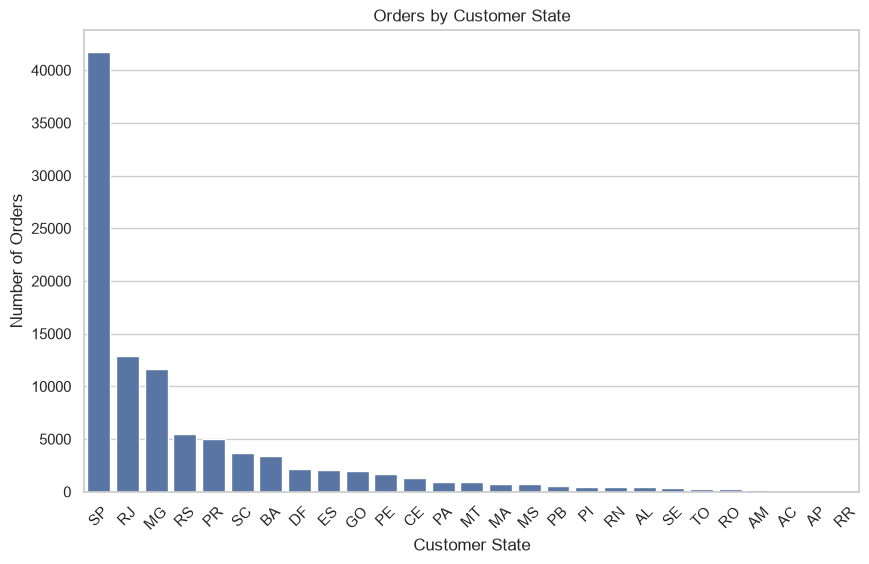

In [16]:
if "customer_state" in df.columns:
    sns.countplot(
        data=df,
        x="customer_state",
        order=df["customer_state"].value_counts().index
    )
    
plt.title("Orders by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

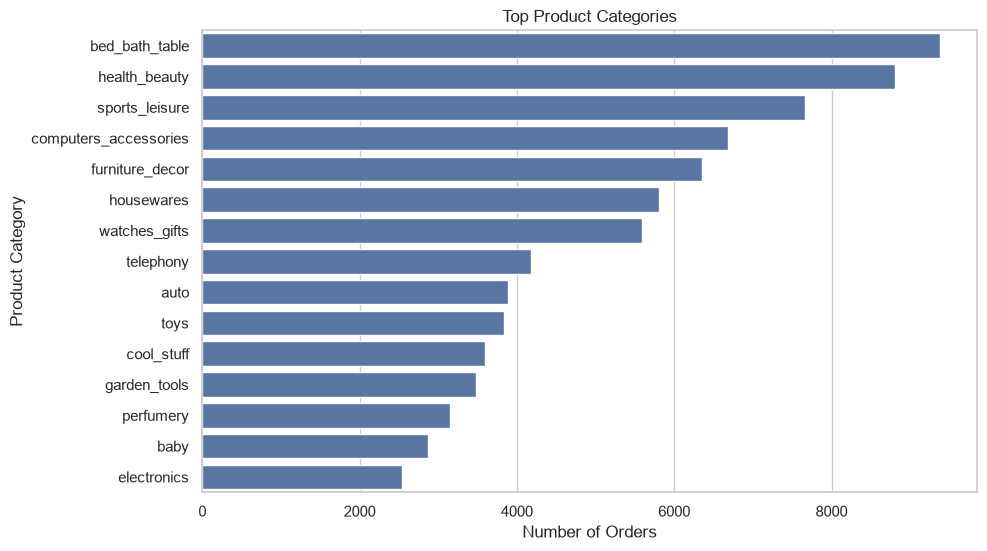

In [17]:
if "main_product_category" in df.columns:
    top_categories = df["main_product_category"].value_counts().head(15).index

    sns.countplot(
        data=df[df["main_product_category"].isin(top_categories)],
        y="main_product_category",
        order=top_categories
    )

    plt.title("Top Product Categories")
    plt.xlabel("Number of Orders")
    plt.ylabel("Product Category")
    plt.show()

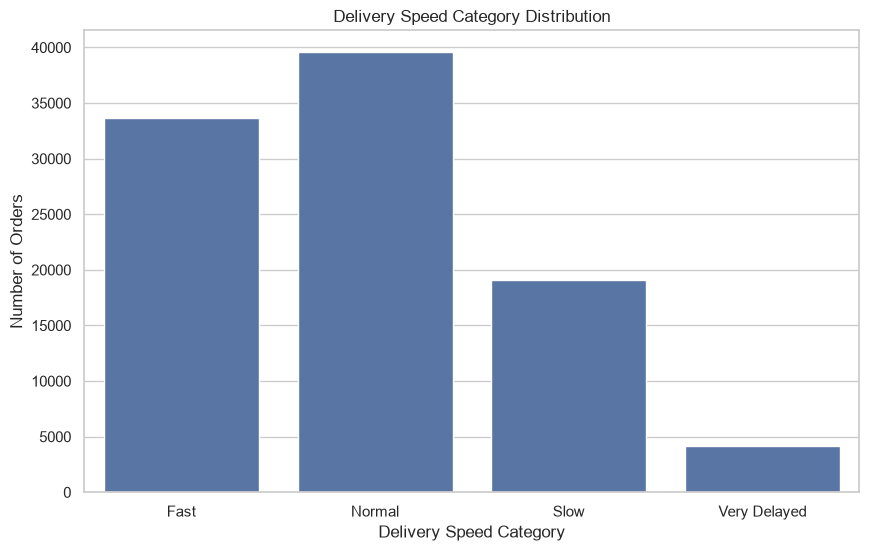

In [18]:
if "delivery_speed_category" in df.columns:
    delivery_order = ["Fast", "Normal", "Slow", "Very Delayed"]

    sns.countplot(
        data=df,
        x="delivery_speed_category",
        order=delivery_order
    )

plt.title("Delivery Speed Category Distribution")
plt.xlabel("Delivery Speed Category")
plt.ylabel("Number of Orders")
plt.show()

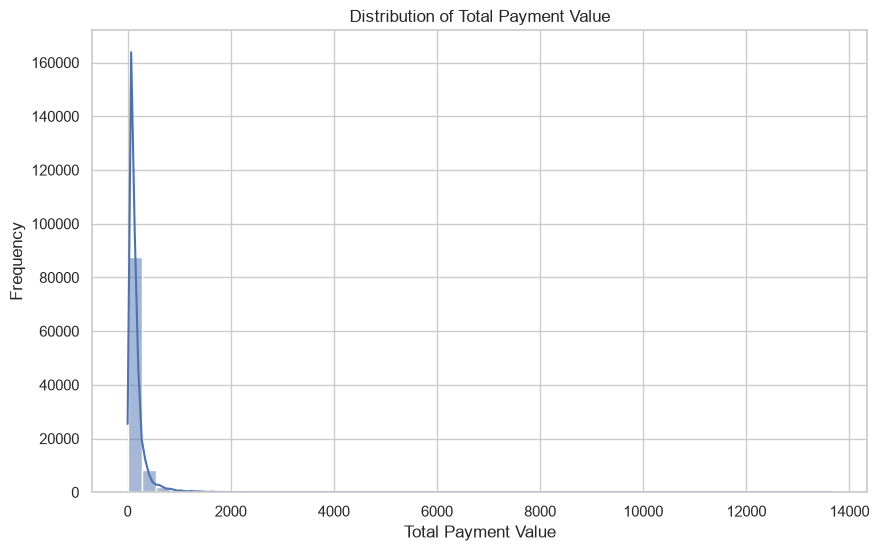

In [19]:
if "total_payment_value" in df.columns:
    sns.histplot(
        data=df,
        x="total_payment_value",
        bins=50,
        kde=True
    )

plt.title("Distribution of Total Payment Value")
plt.xlabel("Total Payment Value")
plt.ylabel("Frequency")
plt.show()


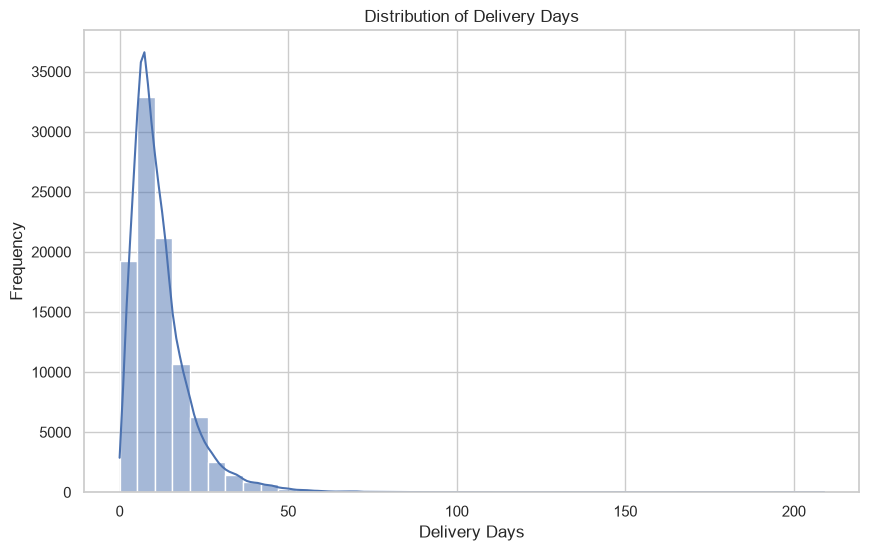

In [20]:
#filtered = df[df["delivery_days"].between(0, 40)] #-> Other data points are not used; it changes the data being analyzed

# "filtered" in df.columns:
#sns.histplot(
#    data=filtered,
#   x="delivery_days",
#   bins=40,
#   kde=True
#)
#plt.xlim(0, 50) - It will zoom on 0-50 but other points are also there but not visible

if "delivery_days" in df.columns:
    sns.histplot(
        data=df,
        x="delivery_days",
        bins=40,
        kde=True
    )
plt.title("Distribution of Delivery Days")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()

Delivery Days distribution is right-skewed because most orders have relatively low delivery times, while a small number of orders take much longer, creating a long tail toward the right.

In [21]:
skew_cols = [
    'total_payment_value',
    'total_price',
    'total_freight',
    'delivery_days',
    'delivery_delay_days',
    'total_items'
]

skew_cols = keep_existing_columns(df, skew_cols)

skewness_values = df[skew_cols].skew().sort_values(ascending=False)

skewness_values


total_freight          12.052723
total_price             9.727741
total_payment_value     9.150169
total_items             7.527006
delivery_days           3.828790
delivery_delay_days     2.014360
dtype: float64

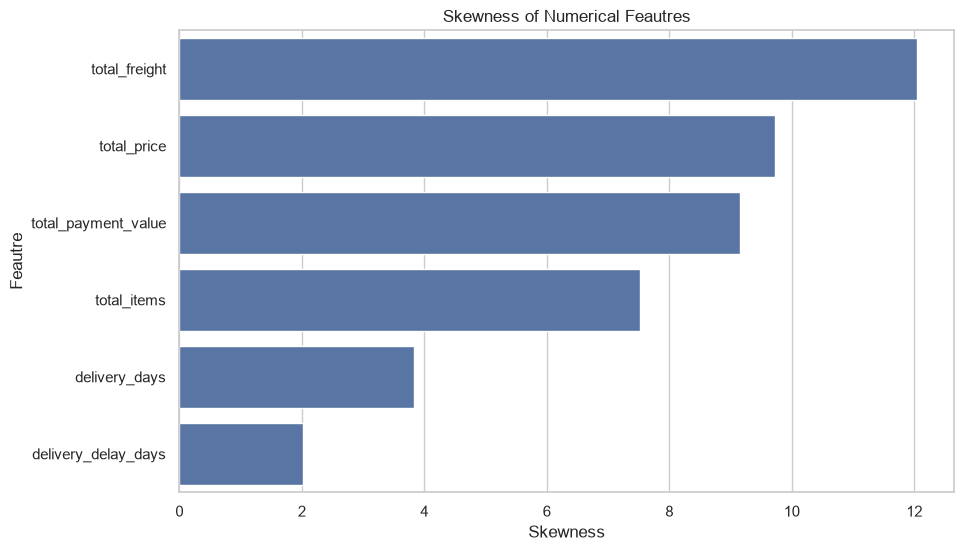

In [22]:
sns.barplot(
    x=skewness_values.values,
    y=skewness_values.index
)

plt.title("Skewness of Numerical Feautres")
plt.xlabel("Skewness")
plt.ylabel("Feautre")
plt.show()

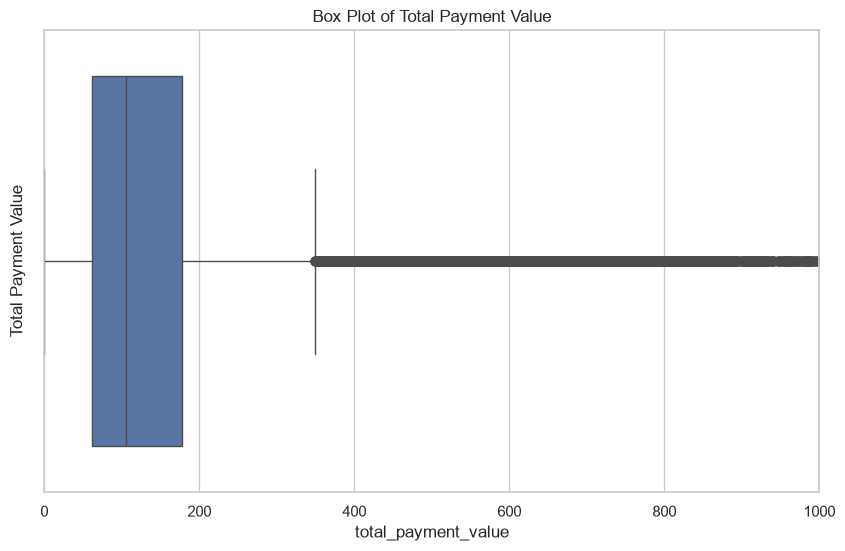

In [23]:
if "total_payment_value" in df.columns:
    sns.boxplot(
        data=df,
        x="total_payment_value"
    )
plt.xlim(0,1000)
plt.title("Box Plot of Total Payment Value")
plt.ylabel("Total Payment Value")
plt.show()

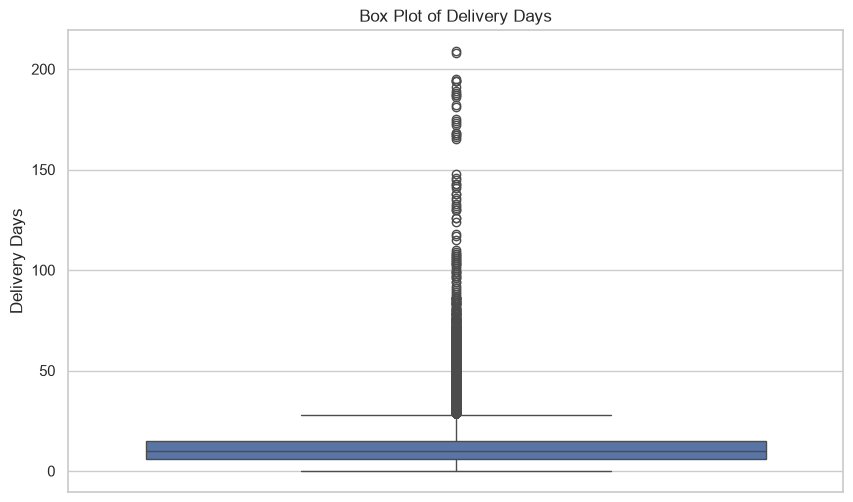

In [24]:
if "delivery_days" in df.columns:
    sns.boxplot(
        data=df,
        y="delivery_days"
    )

    plt.title("Box Plot of Delivery Days")
    plt.ylabel("Delivery Days")
    plt.show()



In [25]:
def iqr_outlier_summary(dataframe, column):
    q1 = dataframe[column].quantile(0.25)
    q3 = dataframe[column].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = dataframe[
        (dataframe[column] < lower_bound) |
        (dataframe[column] > upper_bound)
    ]

    summary = {
        "column": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers),
        "outlier_percent": (len(outliers) / len(dataframe)) * 100
    }

    return summary


In [26]:
if "total_payment_value" in df.columns:
    iqr_outlier_summary(df, "total_payment_value")

if "delivery_days" in df.columns:
    iqr_outlier_summary(df, "delivery_days")

In [27]:
if "total_payment_value" in df.columns:
    result = iqr_outlier_summary(df, "total_payment_value")
    print(result)

{'column': 'total_payment_value', 'q1': np.float64(62.01), 'q3': np.float64(176.97), 'iqr': np.float64(114.96000000000001), 'lower_bound': np.float64(-110.43), 'upper_bound': np.float64(349.40999999999997), 'outlier_count': 7866, 'outlier_percent': 7.910218119286813}


In [28]:
if "delivery_days" in df.columns:
    result = iqr_outlier_summary(df, "delivery_days")
    print(result)

{'column': 'delivery_days', 'q1': np.float64(6.0), 'q3': np.float64(15.0), 'iqr': np.float64(9.0), 'lower_bound': np.float64(-7.5), 'upper_bound': np.float64(28.5), 'outlier_count': 5025, 'outlier_percent': 5.053247654388029}


### Interpretation Questions

**1. Which feature has more outliers?**  
IQR outlier analysis makes sense mainly for numerical features. Qualitative features such as state, city, payment type, etc. do not have meaningful outliers in the same way. So, we can compare the outlier counts/percentages of relevant numerical features.

**2. Should we always remove outliers?**  
No, it depends on the situation and the problem. An outlier may represent a genuine and important observation, so we should understand why it is an outlier before removing it.

**3. What could a high-value order mean in business?**  
A high-value order means an order with an unusually high total payment value. We can investigate which items were in the order, how many items there were, the product prices, freight/shipping charges, and other payment components to understand why the order value was high.

**4. What could a very long delivery time indicate?**  
A very long delivery time means the order took unusually long to be delivered. It could indicate a delivery issue or an unusual case, so we can investigate factors such as the expected delivery time, location, seller, or other order details.